In [5]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd

adult = fetch_openml(name="adult", version=2, as_frame=True)
X = adult.data.astype({c: object for c in adult.data.select_dtypes("category")})
y = (adult.target == ">50K").astype(int)

X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_train, y_train))

X_train.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,29304.000000,2.930400e+04,29304.000000,29304.000000,29304.000000,29304.000000
mean,38.691339,1.896115e+05,10.080672,1058.973485,89.329887,40.531463
std,13.722432,1.043106e+05,2.578193,7335.770856,407.294857,12.424274
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.179780e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.782465e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.374412e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.455435e+06,16.000000,99999.000000,4356.000000,99.000000


## Assignment 2

# Q 1.1

In [6]:
# Q1.1
n_miss = X_train.isna().sum()
print(pd.DataFrame({"missing": n_miss, "pct": (100 * n_miss / len(X_train)).round(2)}).query("missing > 0"))
print("rows with any missing:", X_train.isna().any(axis=1).sum())

wc_na, occ_na = X_train["workclass"].isna(), X_train["occupation"].isna()
print(pd.crosstab(wc_na, occ_na))                                  # missing together?
print(X_train.loc[occ_na & ~wc_na, "workclass"].value_counts())   # the exceptions
for col in ["workclass", "occupation", "native-country"]:           # >50K share: present / missing
    print(col, y_train.groupby(X_train[col].isna()).mean().round(3).to_dict())
print(y_train.groupby(X_train["occupation"]).agg(["size", "mean"]).nlargest(3, "size"))  # mode candidates

                missing   pct
workclass          1694  5.78
occupation         1700  5.80
native-country      493  1.68
rows with any missing: 2166
occupation  False  True 
workclass               
False       27604      6
True            0   1694
workclass
Never-worked    6
Name: count, dtype: int64
workclass {False: 0.248, True: 0.097}
occupation {False: 0.248, True: 0.096}
native-country {False: 0.239, True: 0.245}
                 size      mean
occupation                     
Prof-specialty   3745  0.446195
Craft-repair     3692  0.226165
Exec-managerial  3691  0.477377


# Q 1.2

In [7]:
num = X_train.select_dtypes("number")
q1, q3 = num.quantile(0.25), num.quantile(0.75)
iqr_flags = ((num < q1 - 1.5 * (q3 - q1)) | (num > q3 + 1.5 * (q3 - q1))).sum()
z_flags = (((num - num.mean()) / num.std()).abs() > 3).sum()
print(pd.DataFrame({"IQR": iqr_flags, "z": z_flags, "nonzero": (num != 0).sum()}))

big = num["capital-gain"] == 99999
print("largest capital-gain values:", sorted(num["capital-gain"].unique())[-3:])
print("= 99999:", big.sum(), "| >50K share:", round(y_train[big].mean(), 3),
      "| >50K share when capital-gain > 0:", round(y_train[num["capital-gain"] > 0].mean(), 3))

                 IQR     z  nonzero
age              120   104    29304
fnlwgt           878   305    29304
education-num   1063   204    29304
capital-gain    2396   194     2396
capital-loss    1395  1352     1395
hours-per-week  8147   421    29304
largest capital-gain values: [np.int64(34095), np.int64(41310), np.int64(99999)]
= 99999: 141 | >50K share: 1.0 | >50K share when capital-gain > 0: 0.611


# Q 1.3

In [8]:
# Q1.3
cat = X_train.select_dtypes("object").fillna("Missing")   # "Missing" as its own category
share = {c: cat[c].value_counts(normalize=True) for c in cat}

def n_after(s, t):
    return (s >= t).sum() + (s < t).any()

print(pd.DataFrame({f"{t:.1%}": {c: n_after(s, t) for c, s in share.items()} for t in [0, 0.005, 0.01, 0.02]}))
print({c: round(100 * s[s < 0.01].sum(), 2) for c, s in share.items()})   # % of rows moved to Other at 1%
print(share["native-country"].head(6).round(4))

                0.0%  0.5%  1.0%  2.0%
workclass          9     8     8     8
education         16    16    15     9
marital-status     7     7     7     6
occupation        15    14    14    13
relationship       6     6     6     6
race               5     5     4     4
sex                2     2     2     2
native-country    42     5     4     2
{'workclass': np.float64(0.06), 'education': np.float64(0.7), 'marital-status': np.float64(0.09), 'occupation': np.float64(0.52), 'relationship': np.float64(0.0), 'race': np.float64(1.83), 'sex': np.float64(0.0), 'native-country': np.float64(6.6)}
native-country
United-States    0.8978
Mexico           0.0194
Missing          0.0168
Philippines      0.0064
Germany          0.0043
Puerto-Rico      0.0037
Name: proportion, dtype: float64


# Q1.4

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print(X_train.groupby("education")["education-num"].nunique().max(), X_train["education-num"].nunique())

nominal = [c for c in X_train.select_dtypes("object") if c != "education"]
onehot = make_pipeline(SimpleImputer(strategy="constant", fill_value="Missing"),
                       OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist"))
print(onehot.fit_transform(X_train[nominal]).shape)

1 16
(29304, 45)


# Q1.5

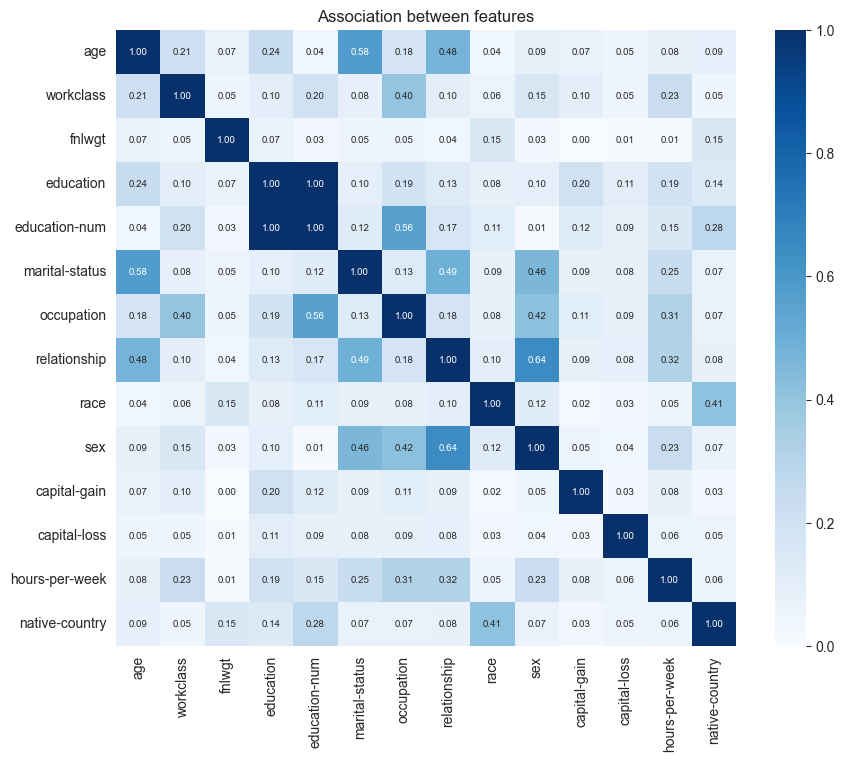

education       education-num     1.000
relationship    sex               0.645
age             marital-status    0.579
education-num   occupation        0.560
marital-status  relationship      0.489
age             relationship      0.475
marital-status  sex               0.460
occupation      sex               0.421
dtype: float64


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = X_train.fillna("Missing")

def assoc(x, y):
    if x.dtype != object and y.dtype != object:
        return abs(x.corr(y))
    if x.dtype != object:
        x, y = y, x
    if y.dtype != object:
        return np.sqrt(y.groupby(x).transform("mean").var() / y.var())
    t = pd.crosstab(x, y)
    return np.sqrt(chi2_contingency(t, correction=False)[0] / (len(x) * (min(t.shape) - 1)))

A = pd.DataFrame([[assoc(df[a], df[b]) for b in df] for a in df], index=df.columns, columns=df.columns)
plt.figure(figsize=(10, 8))
sns.heatmap(A, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, annot_kws={"size": 7})
plt.title("Association between features")
plt.savefig("q1_5_heatmap.pdf", bbox_inches="tight"); plt.show()

pairs = A.where(np.triu(np.ones(A.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
print(pairs.head(8).round(3))

# Q1.6

In [11]:
from scipy import stats

rows = []
for c in X_train.drop(columns="education"):
    x, n = X_train[c], len(X_train)
    if x.dtype == object:
        stat, _, dof, _ = stats.chi2_contingency(pd.crosstab(x.fillna("Missing"), y_train), correction=False)
        rows.append((c, "chi-square", np.sqrt(stat / n), stats.chi2.logsf(stat, dof)))
    else:
        r = y_train.corr(x)
        tstat = abs(r) * np.sqrt((n - 2) / (1 - r**2))
        rows.append((c, "point-biserial", abs(r), np.log(2) + stats.t.logsf(tstat, n - 2)))

res = pd.DataFrame(rows, columns=["feature", "test", "effect", "log10 p"]).set_index("feature")
res["log10 p"] /= np.log(10)
print(res.sort_values("log10 p").round(3))

                          test  effect  log10 p
feature                                        
age             point-biserial   0.229     -inf
education-num   point-biserial   0.334     -inf
marital-status      chi-square   0.452     -inf
occupation          chi-square   0.349     -inf
relationship        chi-square   0.457     -inf
capital-gain    point-biserial   0.221     -inf
hours-per-week  point-biserial   0.226     -inf
sex                 chi-square   0.217 -301.164
workclass           chi-square   0.177 -191.829
capital-loss    point-biserial   0.155 -156.288
race                chi-square   0.104  -66.713
native-country      chi-square   0.099  -38.179
fnlwgt          point-biserial   0.004   -0.343


# Q1.7

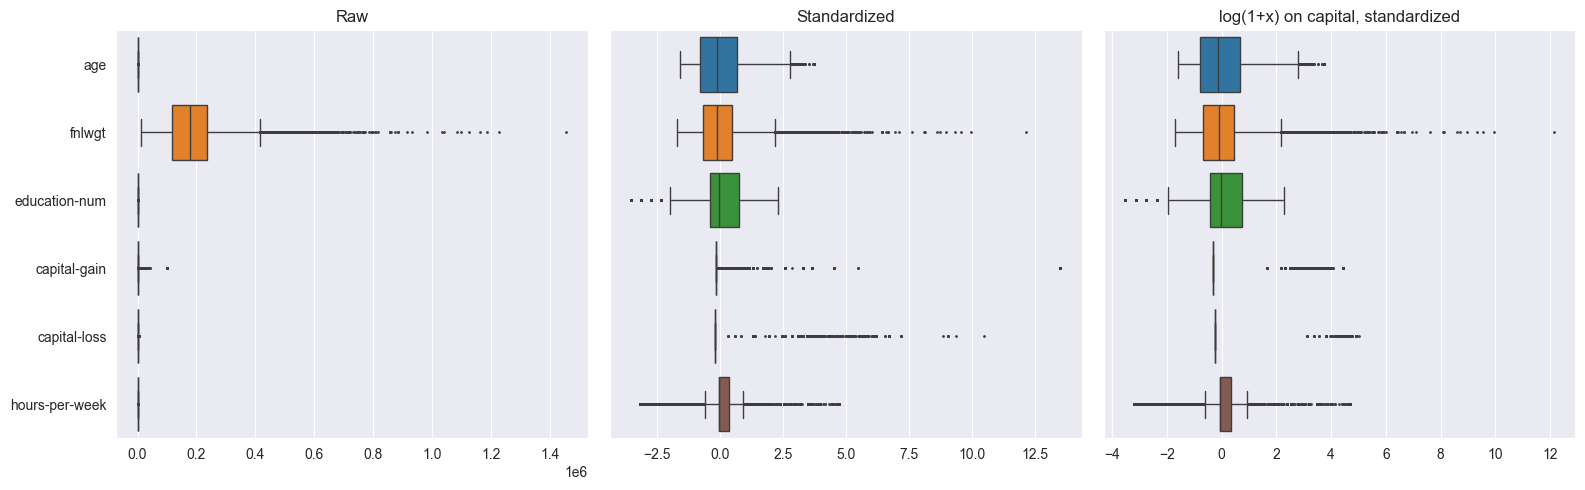

                    Raw  Standardized  log(1+x) on capital, standardized
age                  90           3.7                                3.7
fnlwgt          1455435          12.1                               12.1
education-num        16           2.3                                2.3
capital-gain      99999          13.5                                4.4
capital-loss       4356          10.5                                5.0
hours-per-week       99           4.7                                4.7


In [12]:
from sklearn.preprocessing import StandardScaler

num = X_train.select_dtypes("number")
logged = num.copy()
logged[["capital-gain", "capital-loss"]] = np.log1p(logged[["capital-gain", "capital-loss"]])
versions = {"Raw": num,
            "Standardized": pd.DataFrame(StandardScaler().fit_transform(num), columns=num.columns),
            "log(1+x) on capital, standardized": pd.DataFrame(StandardScaler().fit_transform(logged), columns=num.columns)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (title, d) in zip(axes, versions.items()):
    sns.boxplot(data=d, orient="h", ax=ax, fliersize=1)
    ax.set_title(title)
plt.tight_layout(); plt.savefig("q1_7_scaling.pdf", bbox_inches="tight"); plt.show()

print(pd.DataFrame({k: d.max() for k, d in versions.items()}).round(1))

# Q1.8

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

capital = ["capital-gain", "capital-loss"]
numeric = ["age", "fnlwgt", "education-num", "hours-per-week"]
nominal = ["workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

preprocess = ColumnTransformer([
    ("capital", make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler()), capital),
    ("numeric", StandardScaler(), numeric),
    ("nominal", make_pipeline(SimpleImputer(strategy="constant", fill_value="Missing"),
                              OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist")), nominal),
], sparse_threshold=0)

Z_train = preprocess.fit_transform(X_train)
Z_val, Z_test = preprocess.transform(X_val), preprocess.transform(X_test)
print(Z_train.shape, Z_val.shape, Z_test.shape)

print(pd.DataFrame({"train": preprocess.named_transformers_["numeric"].mean_,
                    "all data": StandardScaler().fit(X[numeric]).mean_}, index=numeric).round(3))

(29304, 51) (9769, 51) (9769, 51)
                     train    all data
age                 38.691      38.644
fnlwgt          189611.493  189664.135
education-num       10.081      10.078
hours-per-week      40.531      40.422
